In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')

con = duckdb.connect(database=':memory:')

## Integrity checks and adoption

Dedup integrity, mining runs, and monthly adoption of SKILL.md since launch.


#### Integrity checks
The dedup flag must mark exactly 1 representation per file hash.

In [2]:
representatives = con.execute(f"""
    SELECT COUNT(*)                  AS rows_total,
       SUM(dedup_primary)        AS representatives,
       COUNT(DISTINCT file_sha)  AS distinct_hashes,
       (SELECT COUNT(*) FROM (SELECT file_sha FROM read_parquet('{artifacts_path}') GROUP BY file_sha
                              HAVING SUM(dedup_primary) <> 1)) AS bad_groups,
       SUM(dedup_primary = 1 AND (content IS NULL OR content = '')) AS reps_without_text,
       SUM(dedup_primary = 0 AND content IS NOT NULL AND content <> '') AS copies_with_text
FROM read_parquet('{artifacts_path}')
""").df()
representatives.T.rename(columns={0: "value"}).astype(int)

,value
rows_total,3797117
representatives,1877981
distinct_hashes,1877981
bad_groups,0
reps_without_text,0
copies_with_text,2348


Total number of artifacts: 3797117. \
Total number of unique file hashes: 1877981

Content should be empty when dedup_primary is 0, and non-empty when dedup_primary is 1. This is by design to save space.
There are some records which are not empty though they are marked as duplicates. This number is harmless. It will not affect our analysis in any way.


In [3]:
runs = con.execute(f"SELECT * FROM read_parquet('{mining_runs_path}')").df()
runs

,run_id,artifact_type,query,started_at,finished_at,discovered,note
0,1,agent-skills,filename:SKILL.md,2026-07-09T17:26:45.768703+00:00,2026-07-09T18:04:34.751737+00:00,11796,NaN
1,2,agent-skills,filename:SKILL.md,2026-07-09T18:07:39.150068+00:00,2026-07-12T06:54:51.308396+00:00,1328473,NaN
2,3,agent-skills,filename:SKILL.md,2026-07-12T06:59:13.601456+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before f...
3,4,agent-skills,filename:SKILL.md,2026-07-13T12:52:52.309967+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before f...
4,5,agent-skills,filename:SKILL.md,2026-07-14T18:04:23.050325+00:00,2026-07-20T05:23:31.638481+00:00,1657948,NaN
5,6,agent-skills,filename:SKILL.md,2026-07-20T05:28:44.667482+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before f...
6,7,agent-skills,filename:SKILL.md,2026-07-20T07:38:28.581854+00:00,2026-07-20T22:26:56.553671+00:00,0,closed retroactively: process crashed before f...


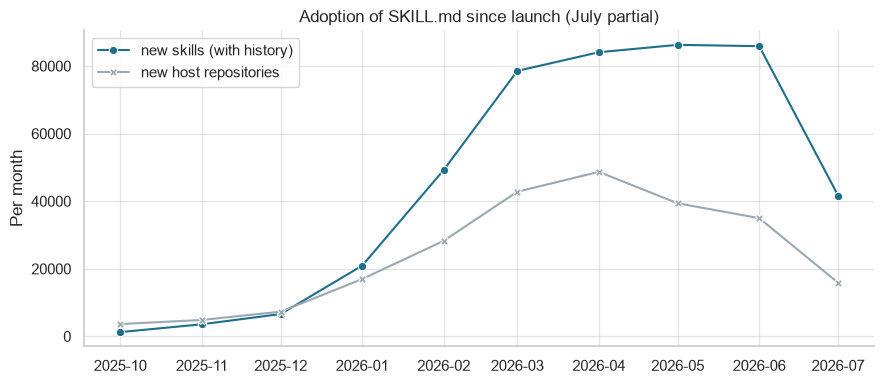

,month,new_skills,new_repos
0,2025-10-01,1265,3646
1,2025-11-01,3578,4855
2,2025-12-01,6615,7314
3,2026-01-01,20918,16961
4,2026-02-01,49234,28264
5,2026-03-01,78540,42796
6,2026-04-01,84062,48669
7,2026-05-01,86254,39374
8,2026-06-01,85855,34982
9,2026-07-01,41664,15862


In [4]:
adoption = con.execute(f"""
WITH s AS (
  SELECT date_trunc('month', CAST(first_commit_at AS TIMESTAMP))::DATE AS month, COUNT(*) AS new_skills
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1 AND history_fetched = 1 AND first_commit_at >= '2025-10-01'
  GROUP BY 1
), r AS (
  SELECT date_trunc('month', CAST(created_at AS TIMESTAMP))::DATE AS month, COUNT(*) AS new_repos
  FROM read_parquet('{repos_path}')
  WHERE created_at >= '2025-10-01'
  GROUP BY 1
)
SELECT month, new_skills, new_repos FROM s FULL JOIN r USING (month) ORDER BY month
""").df().fillna(0)
long = adoption.melt(id_vars="month", value_vars=["new_skills", "new_repos"], var_name="series", value_name="count")
long["series"] = long.series.map({"new_skills": "new skills (with history)", "new_repos": "new host repositories"})
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=long, x="month", y="count", hue="series", style="series", markers=True, dashes=False,
             palette=PAIR, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Per month"); ax.legend(title="")
ax.set_title("Adoption of SKILL.md since launch (July partial)")
plt.tight_layout(); plt.show()
adoption